# 01 — Аудио и признаки

Что вообще видит модель: одна запись в трёх видах — сигнал, спектрограмма, кэшированные признаки `[T, C]`. Плюс сравнение подлинной и спуф-записи в общей цветовой шкале.

Ноутбук **тонкий** (§7): логика — в `src/viz/audio.py`, здесь только вызовы. Признаки не пересчитываются, читается готовый кэш Стадии 1 (§6); аудио декодируется тем же кодом, что и на Стадии 1, чтобы картинка не рассогласовалась с кэшем.

**Предусловие:** прогнаны Стадия 0 (манифест) и Стадия 1 (кэш признаков) для выбранного датасета.

In [6]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import Paths
from src.data.features import get_extractor
from src.viz import audio as A
from src.viz.style import apply_style, save_figure

apply_style()
PATHS = Paths(root=ROOT)

DATASET = "asvspoof2019_la"
SPLIT = "train"
EXTRACTOR = get_extractor("lfcc")   # тот же признак, что в конфиге прогона
T_FIXED = 400                        # из data.t_fixed конфига Стадии 2
SEED = 1337

print(f"{EXTRACTOR.name}: C={EXTRACTOR.channels}, sr={EXTRACTOR.target_sr}, "
      f"hop={EXTRACTOR.hop_length}, кэш={EXTRACTOR.cache_dir(PATHS).name}")

lfcc: C=60, sr=16000, hop=160, кэш=lfcc-b699fee0f7


## Одна запись в трёх видах

Красная линия — граница `t_fixed`: правее неё сигнал отбрасывается кропом, а запись короче неё повторяется до этой длины (§7).

[PosixPath('/home/vano/Programming/Study/Python/ITMO-NIR-MAG/reports/figures/asvspoof2019_la_example_spoof.png')]

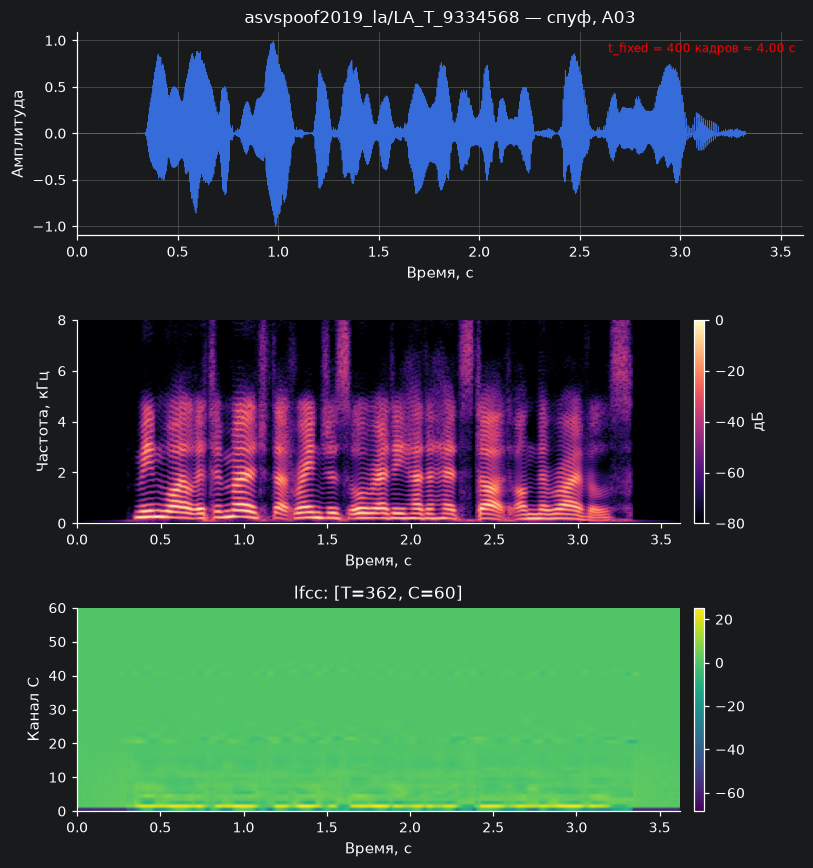

In [7]:
row = A.pick_examples(PATHS, DATASET, label=1, split=SPLIT, seed=SEED).iloc[0]
fig = A.plot_example(PATHS, row, EXTRACTOR, t_fixed=T_FIXED)
save_figure(fig, f"{DATASET}_example_spoof", paths=PATHS, formats=("png",))  # растр (§7)

[PosixPath('/home/vano/Programming/Study/Python/ITMO-NIR-MAG/reports/figures/asvspoof2019_la_example_bonafide.png')]

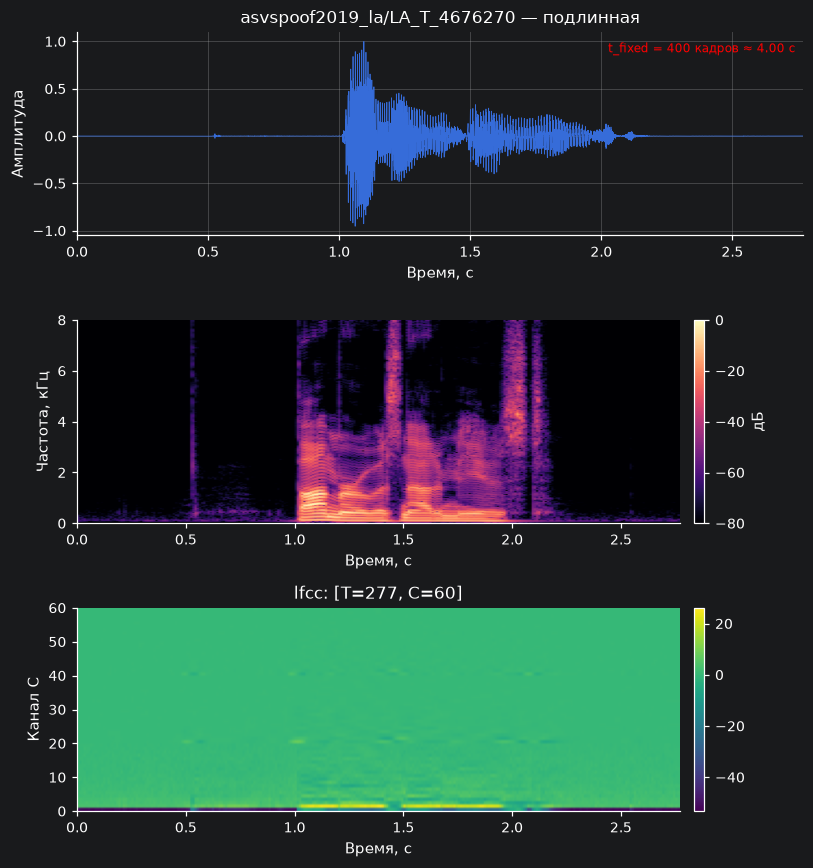

In [8]:
row_bona = A.pick_examples(PATHS, DATASET, label=0, split=SPLIT, seed=SEED).iloc[0]
fig = A.plot_example(PATHS, row_bona, EXTRACTOR, t_fixed=T_FIXED)
save_figure(fig, f"{DATASET}_example_bonafide", paths=PATHS, formats=("png",))

## Подлинная против спуфа

Общая цветовая шкала обязательна: при раздельной нормировке «разница» на картинке была бы артефактом раскраски.

Честная оговорка: по одной паре записей нельзя делать вывод о том, чем классы различаются — это иллюстрация, а не доказательство. Численный ответ даёт Стадия 3.

[PosixPath('/home/vano/Programming/Study/Python/ITMO-NIR-MAG/reports/figures/asvspoof2019_la_pair_lfcc.png')]

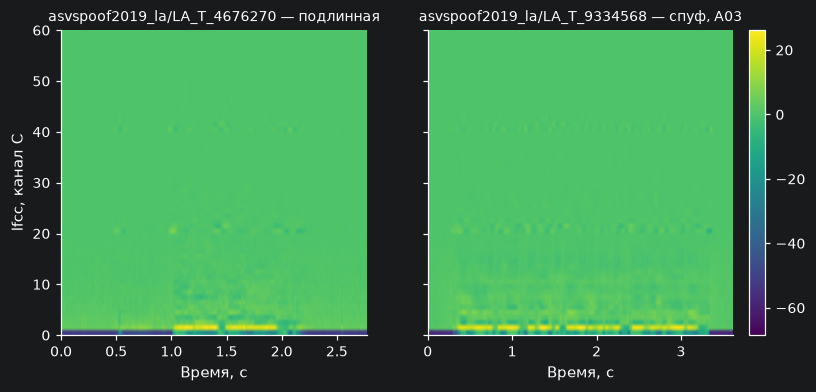

In [9]:
fig = A.plot_class_pair(PATHS, DATASET, EXTRACTOR, split=SPLIT, seed=SEED)
save_figure(fig, f"{DATASET}_pair_{EXTRACTOR.name}", paths=PATHS, formats=("png",))

## Разные атаки

Признаки нескольких атак подряд: видно, что «спуф» — это не один тип сигнала, а семейство очень разных. Ровно поэтому в §8 требуется разбивка EER по атакам, а не одно среднее число.

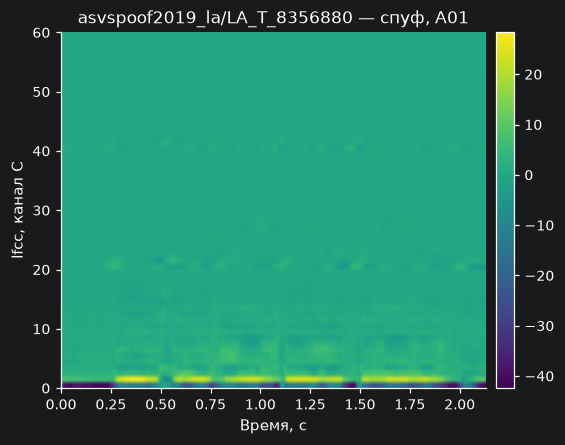

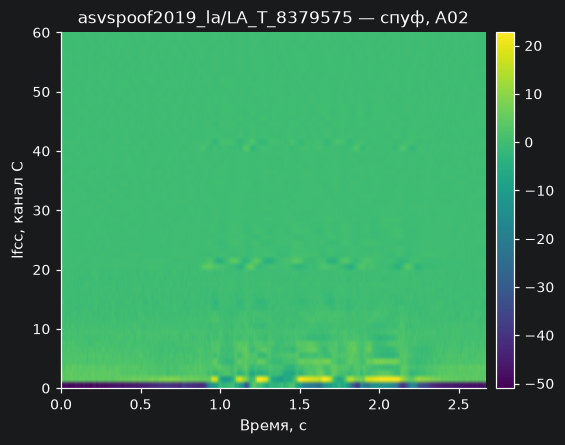

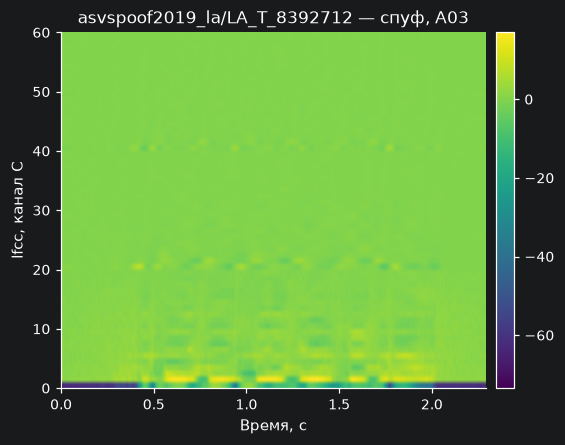

In [10]:
import pandas as pd

manifest = pd.read_parquet(PATHS.manifest_path(DATASET))
attacks = sorted(manifest.loc[manifest["split"] == SPLIT, "attack_type"].dropna().unique())[:3]

for attack in attacks:
    r = A.pick_examples(PATHS, DATASET, split=SPLIT, attack_type=attack, seed=SEED).iloc[0]
    arr = A.load_feature(PATHS, r, EXTRACTOR)
    ax = A.plot_feature_map(arr, hop_length=EXTRACTOR.hop_length, sr=EXTRACTOR.target_sr,
                            title=A.describe(r), channel_label=f"{EXTRACTOR.name}, канал C")
    save_figure(ax.figure, f"{DATASET}_{attack}_{EXTRACTOR.name}", paths=PATHS,
                formats=("png",))